In [38]:
import os
import glob
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [39]:
df = pd.read_csv("data/nfl_combined.csv")


identifier= ["Player","School"]
target = ["Pos"]
features = ["Ht","Wt","40yd","Vertical","Bench","Broad Jump","3Cone","Shuttle"]
df = df[ identifier + target + features]
print(df.shape)  
df.head()

(7680, 11)


,Player,School,Pos,Ht,Wt,40yd,Vertical,Bench,Broad Jump,3Cone,Shuttle
0,John Abraham,South Carolina,OLB,6-4,252.0,4.55,NaN,NaN,NaN,NaN,NaN
1,Shaun Alexander,Alabama,RB,6-0,218.0,4.58,NaN,NaN,NaN,NaN,NaN
2,Darnell Alford,Boston Col.,OT,6-4,334.0,5.56,25.0,23.0,94.0,8.48,4.98
3,Kyle Allamon,Texas Tech,TE,6-2,253.0,4.97,29.0,NaN,104.0,7.29,4.49
4,Rashard Anderson,Jackson State,CB,6-2,206.0,4.55,34.0,NaN,123.0,7.18,4.15


In [40]:
def ht_to_inches(ht):
    try:
        feet, inches = str(ht).split('-')
        return int(feet) * 12 + int(inches)
    except:
        return np.nan

df["Ht"] = df["Ht"].apply(ht_to_inches)

position_groups = {
    "QB": "Skill",   "RB": "Skill",  "WR": "Skill", "TE": "Skill", "FB": "Skill",
    "OT": "Lineman", "OG": "Lineman","C":  "Lineman","OL": "Lineman",
    "DE": "D-Line",  "DT": "D-Line", "DL": "D-Line","NT": "D-Line","EDGE": "D-Line",
    "LB": "Linebacker","ILB": "Linebacker","OLB": "Linebacker",
    "CB": "Secondary","S":  "Secondary","DB": "Secondary","SS": "Secondary","FS": "Secondary",
    "K":  "Special", "P":  "Special", "LS": "Special"
}

df["Pos"] = df["Pos"].map(position_groups)
df = df.dropna(subset=["Pos"])

imputer = SimpleImputer(strategy='median')
df[features] = imputer.fit_transform(df[features])

le = LabelEncoder()
y = le.fit_transform(df[target[0]])
X = df[features].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Classes: {le.classes_}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Classes: ['D-Line' 'Linebacker' 'Lineman' 'Secondary' 'Skill' 'Special']
Train: (6144, 8) | Test: (1536, 8)


In [41]:
depths = [3, 5, 10, 15, None]
results_depth = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    results_depth.append({"Max Depth": str(d), "Accuracy (%)": round(acc * 100, 2)})
    print(f"Depth {str(d):5} → Accuracy: {acc:.4f}")

df_depth = pd.DataFrame(results_depth)
print("\n", df_depth)


Depth 3     → Accuracy: 0.6152
Depth 5     → Accuracy: 0.6667
Depth 10    → Accuracy: 0.6536
Depth 15    → Accuracy: 0.6315
Depth None  → Accuracy: 0.5964

   Max Depth  Accuracy (%)
0         3         61.52
1         5         66.67
2        10         65.36
3        15         63.15
4      None         59.64


In [42]:
best_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
best_dt.fit(X_train, y_train)
y_pred = best_dt.predict(X_test)

print(" Classification Report ")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Recalling
sample = X_test[0].reshape(1, -1)
prediction = le.inverse_transform(best_dt.predict(sample))
print(f"Recalling example → Predicted position: {prediction[0]}")
print(f"Actual position:    {le.inverse_transform([y_test[0]])[0]}")


 Classification Report 
              precision    recall  f1-score   support

      D-Line       0.67      0.64      0.66       243
  Linebacker       0.56      0.71      0.63       166
     Lineman       0.82      0.80      0.81       250
   Secondary       0.57      0.58      0.57       266
       Skill       0.65      0.62      0.64       554
     Special       0.58      0.54      0.56        57

    accuracy                           0.65      1536
   macro avg       0.64      0.65      0.65      1536
weighted avg       0.66      0.65      0.65      1536

Recalling example → Predicted position: Linebacker
Actual position:    Skill


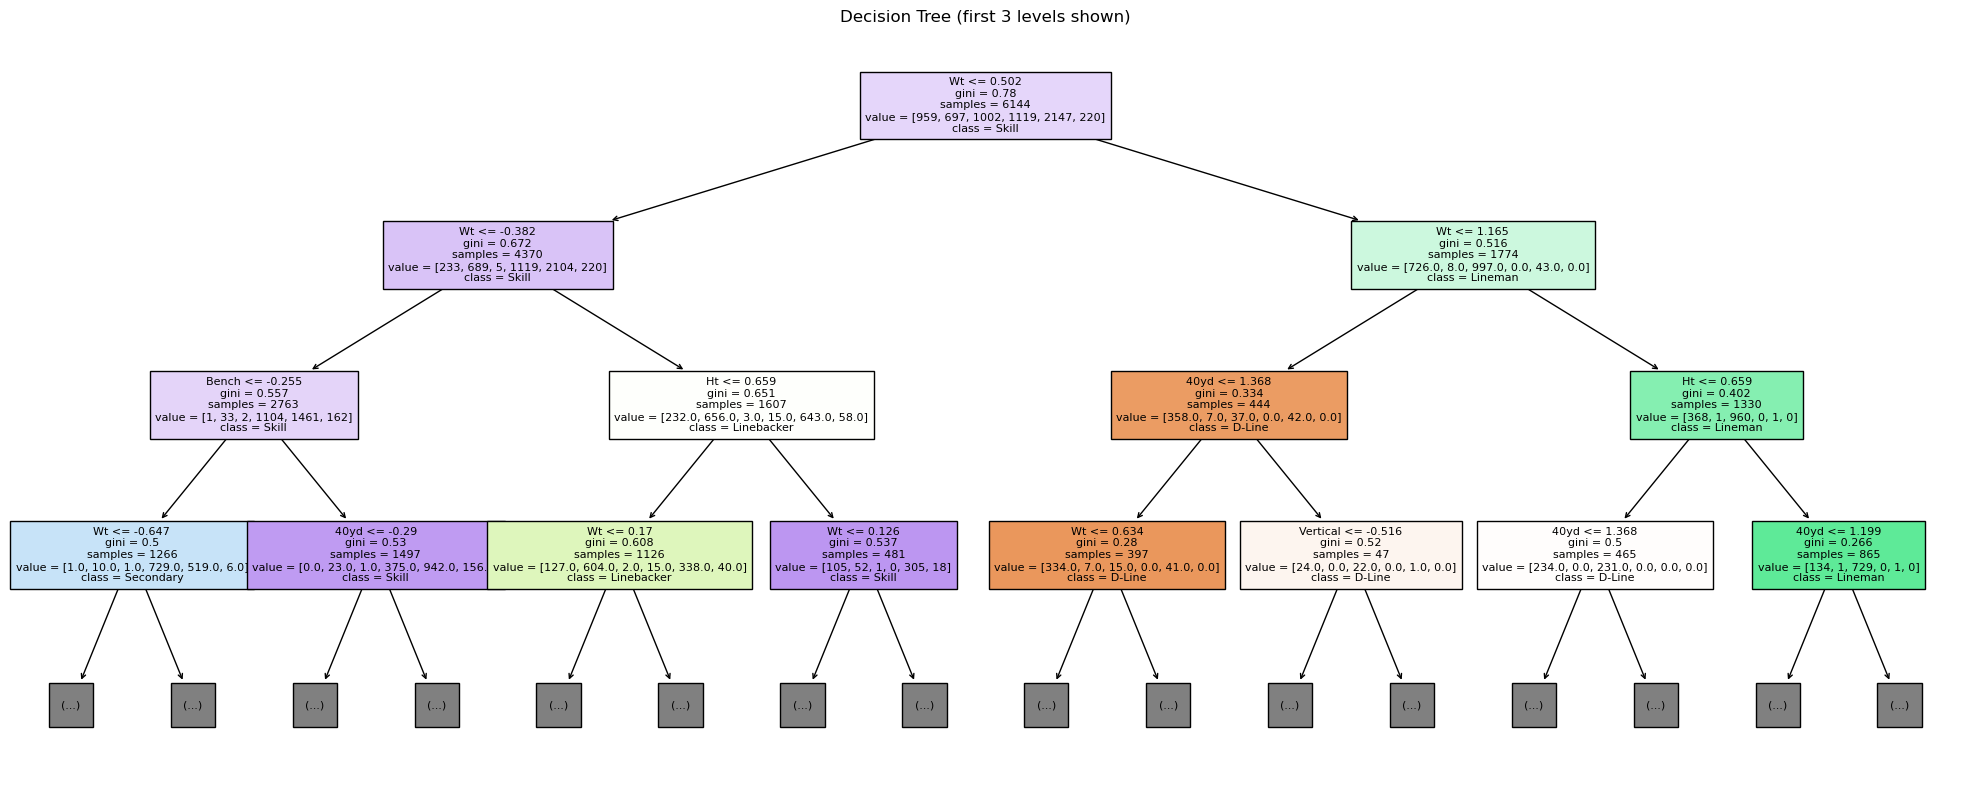

In [43]:
plt.figure(figsize=(20, 8))
plot_tree(best_dt, feature_names=features, class_names=le.classes_,
          filled=True, max_depth=3, fontsize=8)
plt.title("Decision Tree (first 3 levels shown)")
plt.tight_layout()
plt.show()


           Model  Accuracy (%)
0            BPN         71.03
1  Decision Tree         65.36


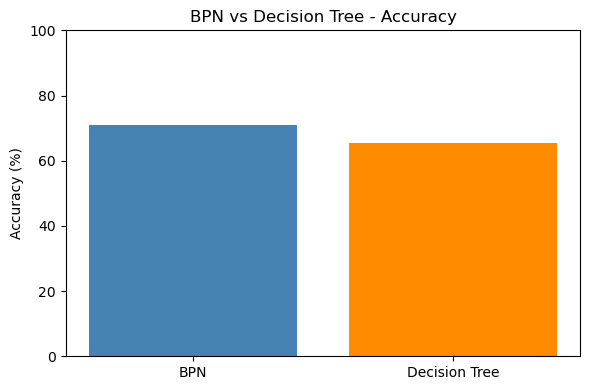

In [44]:
bpn_acc = 0.7103  # reemplaza con tu mejor accuracy del BPN

dt_acc = accuracy_score(y_test, y_pred)

comparison = pd.DataFrame({
    "Model": ["BPN", "Decision Tree"],
    "Accuracy (%)": [round(bpn_acc * 100, 2), round(dt_acc * 100, 2)]
})
print(comparison)

plt.figure(figsize=(6, 4))
plt.bar(comparison["Model"], comparison["Accuracy (%)"], color=["steelblue", "darkorange"])
plt.title("BPN vs Decision Tree - Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()
